# 04 — Manuscript Results Aggregation and Readiness Audit

This notebook aggregates only the revised `manuscript_v2` experiment records. It excludes the preliminary repeated-seed CSV files that produced artificial zero standard deviations.

Outputs include independent-seed summaries, scenario-level bootstrap confidence intervals, paired statistical tests, ablation results, transfer results, and a manuscript-readiness checklist.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from drift_detection.config import load_config

config = load_config()
print(f"Project root: {PROJECT_ROOT}")
print(f"Experiment version: {config['project']['experiment_version']}")
print(f"Scenario profile: {config['experiment']['profile']}")

import matplotlib.pyplot as plt
from drift_detection.aggregation_v2 import aggregate_manuscript_results
from drift_detection.experiments_v2 import manuscript_result_root


Project root: /home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection
Experiment version: manuscript_v2
Scenario profile: manuscript


## Aggregate revised records


In [2]:
outputs = aggregate_manuscript_results(config)
outputs


{'all_runs': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/manuscript_v2/combined/all_runs.csv'),
 'model_summary': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/manuscript_v2/combined/model_summary.csv'),
 'scenario_metrics': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/manuscript_v2/combined/scenario_metrics.csv'),
 'bootstrap_confidence_intervals': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/manuscript_v2/combined/bootstrap_confidence_intervals.csv'),
 'paired_statistical_tests': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/manuscript_v2/combined/paired_statistical_tests.csv'),
 'cross_domain_summary': PosixPath('/home/commu1

## Independent-seed model summary


In [3]:
model_summary = pd.read_csv(outputs["model_summary"])
display(model_summary.sort_values(["dataset", "auprc_mean"], ascending=[True, False]))


,dataset,family,model,variant,precision_mean,precision_std,precision_count,recall_mean,recall_std,recall_count,...,model_size_mb_mean,model_size_mb_std,model_size_mb_count,inference_ms_per_window_mean,inference_ms_per_window_std,inference_ms_per_window_count,training_and_evaluation_seconds_mean,training_and_evaluation_seconds_std,training_and_evaluation_seconds_count,distinct_seed_count
6,gas_sensor,proposed,LCAD_AE,full,0.137442,0.009640,5,0.203602,0.021617,5,...,0.092305,0.000000,5,0.052036,0.002330,5,41.362825,0.845300,5,5
9,gas_sensor,proposed,LCAD_AE,recon_statistics,0.134797,0.008292,5,0.198786,0.019563,5,...,0.092305,0.000000,5,0.053930,0.004603,5,41.404134,0.687155,5,5
2,gas_sensor,baselines,IsolationForest,published_baseline,0.040490,0.006326,5,0.024551,0.007079,5,...,11.017114,0.012935,5,0.363177,0.027072,5,46.179266,0.764230,5,5
11,gas_sensor,transfer,LCAD_AE_transfer,full,0.101333,0.019623,25,0.126966,0.044146,25,...,0.092305,0.000000,25,0.054046,0.008946,25,38.965951,1.162881,25,5
10,gas_sensor,transfer,LCAD_AE_scratch,full,0.100131,0.021741,25,0.122929,0.043780,25,...,0.092305,0.000000,25,0.052398,0.006298,25,39.200568,1.447620,25,5
0,gas_sensor,baselines,ConvAE,published_baseline,0.114880,0.005043,5,0.199843,0.024491,5,...,0.340642,0.000000,5,0.027089,0.002525,5,36.704272,0.198271,5,5
7,gas_sensor,proposed,LCAD_AE,recon_correlation,0.102811,0.008344,5,0.152700,0.021262,5,...,0.092305,0.000000,5,0.060029,0.016749,5,41.183801,0.374158,5,5
8,gas_sensor,proposed,LCAD_AE,recon_only,0.099717,0.008226,5,0.145884,0.020059,5,...,0.092305,0.000000,5,0.053171,0.000832,5,41.217991,0.297154,5,5
4,gas_sensor,baselines,PCA_SPE,published_baseline,0.104019,0.000000,5,0.175884,0.000000,5,...,0.329119,0.000000,5,0.088993,0.028520,5,42.263141,0.601140,5,5
3,gas_sensor,baselines,LSTMAE,published_baseline,0.072911,0.003859,5,0.093827,0.010298,5,...,0.360356,0.000000,5,0.044120,0.002307,5,37.430548,0.618899,5,5


## Cross-domain summary

A model appears here only when it has completed standard experiments in both Gas Sensor and SKAB.


In [4]:
cross_domain = pd.read_csv(outputs["cross_domain_summary"])
display(cross_domain)


,family,model,variant,f1,f1_worst_domain,auprc,auprc_worst_domain,auroc,auroc_worst_domain,event_recall,event_recall_worst_domain,false_positive_rate,false_positive_rate_worst_domain,distinct_seed_count
0,proposed,LCAD_AE,full,0.201647,0.156945,0.370889,0.189601,0.722036,0.623858,0.768056,0.562500,0.257288,0.136410,5
1,baselines,USAD,published_baseline,0.131275,0.055886,0.295017,0.151352,0.630656,0.545007,0.593750,0.294444,0.241890,0.120688,5
2,baselines,LSTMAE,published_baseline,0.147794,0.076540,0.294708,0.158180,0.644590,0.572582,0.569097,0.342361,0.214509,0.130569,5
3,baselines,ConvAE,published_baseline,0.170732,0.138051,0.293598,0.163809,0.639452,0.577686,0.697222,0.516667,0.276760,0.166787,5
4,baselines,DenseAE,published_baseline,0.152100,0.072591,0.292070,0.151884,0.630802,0.541894,0.574653,0.338889,0.192967,0.133672,5
5,baselines,PCA_SPE,published_baseline,0.171491,0.123927,0.286913,0.160352,0.642741,0.572411,0.664931,0.465278,0.231251,0.165327,5
6,baselines,IsolationForest,published_baseline,0.132082,0.028939,0.244916,0.179718,0.596639,0.547533,0.338542,0.093750,0.049339,0.031672,5


## Scenario-level bootstrap confidence intervals


In [5]:
bootstrap = pd.read_csv(outputs["bootstrap_confidence_intervals"])
display(bootstrap.sort_values(["dataset", "auprc_mean"], ascending=[True, False]))


,dataset,family,model,variant,scenario_observation_count,distinct_seed_count,f1_mean,f1_ci_low,f1_ci_high,auprc_mean,...,auroc_ci_high,event_recall_mean,event_recall_ci_low,event_recall_ci_high,false_positive_rate_mean,false_positive_rate_ci_low,false_positive_rate_ci_high,topk_channel_recall_mean,topk_channel_recall_ci_low,topk_channel_recall_ci_high
6,gas_sensor,proposed,LCAD_AE,full,1440,5,0.156945,0.145740,0.168045,0.189601,...,0.634499,0.562500,0.537500,0.586806,0.136410,0.135649,0.137144,0.574171,0.561344,0.587957
9,gas_sensor,proposed,LCAD_AE,recon_statistics,1440,5,0.153605,0.142271,0.164664,0.189187,...,0.633650,0.554861,0.529861,0.578472,0.136410,0.135649,0.137144,0.573606,0.560808,0.587355
2,gas_sensor,baselines,IsolationForest,published_baseline,1440,5,0.028939,0.022971,0.034907,0.179718,...,0.560501,0.093750,0.079167,0.109028,0.031672,0.031396,0.031935,NaN,NaN,NaN
11,gas_sensor,transfer,LCAD_AE_transfer,full,7200,5,0.108909,0.104380,0.113629,0.174953,...,0.563984,0.377361,0.365972,0.388194,0.104695,0.104162,0.105194,0.456646,0.450753,0.462724
10,gas_sensor,transfer,LCAD_AE_scratch,full,7200,5,0.106608,0.102025,0.111233,0.174441,...,0.564849,0.375833,0.364024,0.387083,0.102855,0.102405,0.103308,0.458276,0.452174,0.464383
0,gas_sensor,baselines,ConvAE,published_baseline,1440,5,0.138051,0.128236,0.148130,0.163809,...,0.589363,0.516667,0.490972,0.543750,0.166787,0.165627,0.167968,NaN,NaN,NaN
7,gas_sensor,proposed,LCAD_AE,recon_correlation,1440,5,0.115843,0.106303,0.125798,0.163520,...,0.587028,0.443750,0.418733,0.468767,0.138637,0.137828,0.139441,0.523817,0.510536,0.536863
8,gas_sensor,proposed,LCAD_AE,recon_only,1440,5,0.111535,0.101925,0.121191,0.162810,...,0.584279,0.437500,0.411806,0.462517,0.137934,0.137144,0.138711,0.522874,0.509698,0.535973
4,gas_sensor,baselines,PCA_SPE,published_baseline,1440,5,0.123927,0.114426,0.133673,0.160352,...,0.583592,0.465278,0.438889,0.490972,0.165327,0.164514,0.166110,NaN,NaN,NaN
3,gas_sensor,baselines,LSTMAE,published_baseline,1440,5,0.076540,0.069022,0.084735,0.158180,...,0.583718,0.342361,0.318038,0.367361,0.130569,0.129843,0.131273,NaN,NaN,NaN


## Paired statistical tests

Each proposed-versus-baseline comparison is paired by dataset, random seed, and scenario ID. Holm adjustment controls family-wise multiplicity.


In [6]:
paired = pd.read_csv(outputs["paired_statistical_tests"])
display(paired.sort_values(["dataset", "p_value_holm"]))


,dataset,proposed_model,baseline_model,paired_scenario_count,mean_f1_difference,median_f1_difference,win_rate,wilcoxon_statistic,p_value,p_value_holm
5,gas_sensor,LCAD_AE[full],USAD,1440,0.101059,0.016247,0.525000,2716.0,7.033175e-130,8.439811e-129
2,gas_sensor,LCAD_AE[full],IsolationForest,1440,0.128006,0.025641,0.531250,7174.0,9.665303e-123,1.063183e-121
1,gas_sensor,LCAD_AE[full],DenseAE,1440,0.084354,0.002401,0.513889,8484.5,1.274302e-121,1.274302e-120
3,gas_sensor,LCAD_AE[full],LSTMAE,1440,0.080406,0.000000,0.442361,23966.0,1.956928e-99,1.761236e-98
4,gas_sensor,LCAD_AE[full],PCA_SPE,1440,0.033018,0.000000,0.327778,144315.0,9.107166e-09,5.464300e-08
0,gas_sensor,LCAD_AE[full],ConvAE,1440,0.018894,0.000000,0.279167,191193.5,6.429838e-01,1.000000e+00
6,skab,LCAD_AE[full],ConvAE,1440,0.042934,0.030494,0.601389,302333.5,3.448834e-40,2.759067e-39
11,skab,LCAD_AE[full],USAD,1440,0.039683,0.008639,0.615278,329109.0,3.672718e-28,2.570902e-27
10,skab,LCAD_AE[full],PCA_SPE,1440,0.027292,-0.019883,0.407639,461500.0,6.213534e-03,3.106767e-02
9,skab,LCAD_AE[full],LSTMAE,1440,0.027299,-0.007722,0.409722,465767.0,5.863364e-02,2.345345e-01


## Ablation study


In [7]:
ablation = pd.read_csv(outputs["ablation_summary"])
display(ablation.sort_values(["dataset", "auprc"], ascending=[True, False]))


,dataset,variant,f1,auprc,auroc,event_recall,false_positive_rate,parameter_count
0,gas_sensor,full,0.156945,0.189601,0.623858,0.562500,0.136410,21792.0
3,gas_sensor,recon_statistics,0.153605,0.189187,0.623034,0.554861,0.136410,21792.0
1,gas_sensor,recon_correlation,0.115843,0.163520,0.575293,0.443750,0.138637,21792.0
2,gas_sensor,recon_only,0.111535,0.162810,0.572539,0.437500,0.137934,21792.0
4,skab,full,0.246348,0.552177,0.820213,0.973611,0.378165,6072.0
7,skab,recon_statistics,0.242320,0.547941,0.817387,0.972917,0.393304,6072.0
5,skab,recon_correlation,0.181711,0.425408,0.726191,0.975000,0.599834,6072.0
6,skab,recon_only,0.166034,0.404997,0.693752,0.931250,0.695243,6072.0


## Cross-domain transfer study


In [8]:
transfer = pd.read_csv(outputs["transfer_summary"])
display(transfer.sort_values(["direction", "requested_target_fraction", "initialization"]))


,direction,target_domain,requested_target_fraction,initialization,f1_mean,f1_std,f1_count,auprc_mean,auprc_std,auprc_count,auroc_mean,auroc_std,auroc_count,event_recall_mean,event_recall_std,event_recall_count,false_positive_rate_mean,false_positive_rate_std,false_positive_rate_count
0,gas_to_skab,skab,0.01,scratch,0.335205,0.037458,5,0.394007,0.035996,5,0.588740,0.033729,5,0.602778,0.029422,5,0.025538,0.008756,5
1,gas_to_skab,skab,0.01,transfer,0.359733,0.024269,5,0.403468,0.038392,5,0.596944,0.055186,5,0.627778,0.061253,5,0.020463,0.015694,5
2,gas_to_skab,skab,0.05,scratch,0.339479,0.037679,5,0.393156,0.033898,5,0.588913,0.033457,5,0.600694,0.034109,5,0.023219,0.009584,5
3,gas_to_skab,skab,0.05,transfer,0.364107,0.028722,5,0.404229,0.039301,5,0.596675,0.055267,5,0.622917,0.056502,5,0.017401,0.014325,5
4,gas_to_skab,skab,0.10,scratch,0.388503,0.058187,5,0.492268,0.034580,5,0.717120,0.030903,5,0.679861,0.018602,5,0.045489,0.025086,5
5,gas_to_skab,skab,0.10,transfer,0.419737,0.056213,5,0.494836,0.040004,5,0.720680,0.058734,5,0.697222,0.098772,5,0.031901,0.008334,5
6,gas_to_skab,skab,0.25,scratch,0.417000,0.047344,5,0.519386,0.014131,5,0.767116,0.023413,5,0.804167,0.039938,5,0.062639,0.021480,5
7,gas_to_skab,skab,0.25,transfer,0.386650,0.040324,5,0.499809,0.020154,5,0.750550,0.033056,5,0.779167,0.072610,5,0.075488,0.033086,5
8,gas_to_skab,skab,1.00,scratch,0.246348,0.003680,5,0.552177,0.007812,5,0.820213,0.006490,5,0.973611,0.003106,5,0.378165,0.010358,5
9,gas_to_skab,skab,1.00,transfer,0.246502,0.005307,5,0.545944,0.003179,5,0.818442,0.002739,5,0.969444,0.002905,5,0.371998,0.018567,5


## Performance–complexity visualization


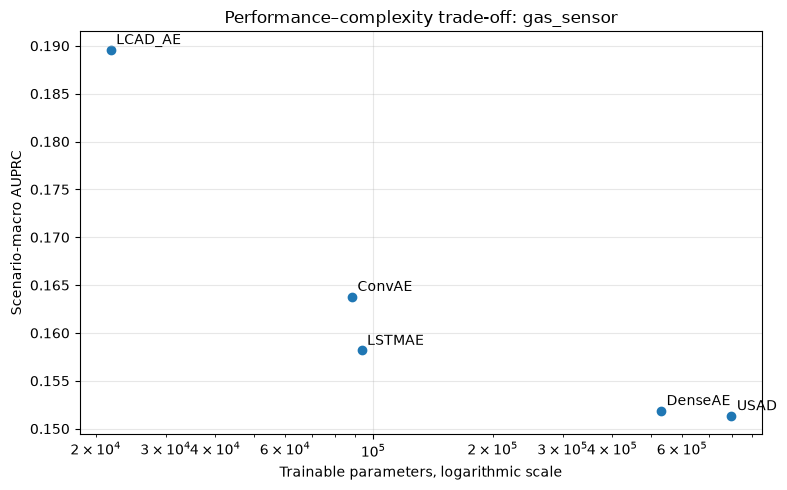

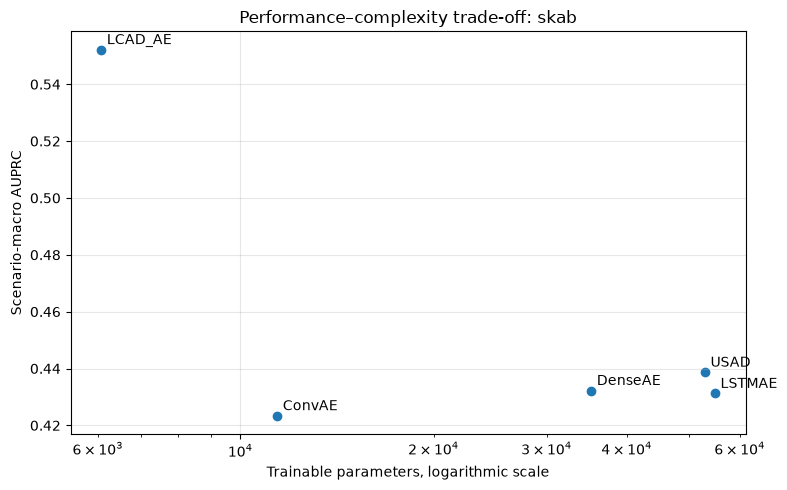

In [9]:
all_runs = pd.read_csv(outputs["all_runs"])
plot_data = all_runs[
    (all_runs["status"] == "completed")
    & (all_runs["family"].isin(["baselines", "proposed"]))
    & ((all_runs["family"] == "baselines") | (all_runs["variant"] == "full"))
].copy()
plot_summary = plot_data.groupby(["dataset", "model"], as_index=False).agg(
    auprc=("auprc", "mean"),
    parameters=("parameter_count", "mean"),
)
plot_summary = plot_summary.dropna(subset=["parameters", "auprc"])
plot_summary = plot_summary[plot_summary["parameters"] > 0]

figure_dir = manuscript_result_root(config) / "combined" / "figures"
figure_dir.mkdir(parents=True, exist_ok=True)
for dataset, frame in plot_summary.groupby("dataset"):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(frame["parameters"], frame["auprc"])
    for _, row in frame.iterrows():
        ax.annotate(row["model"], (row["parameters"], row["auprc"]), xytext=(4, 4), textcoords="offset points")
    ax.set_xscale("log")
    ax.set_xlabel("Trainable parameters, logarithmic scale")
    ax.set_ylabel("Scenario-macro AUPRC")
    ax.set_title(f"Performance–complexity trade-off: {dataset}")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(figure_dir / f"performance_complexity_{dataset}.png", dpi=180)
    plt.show()


## Transfer-learning curve


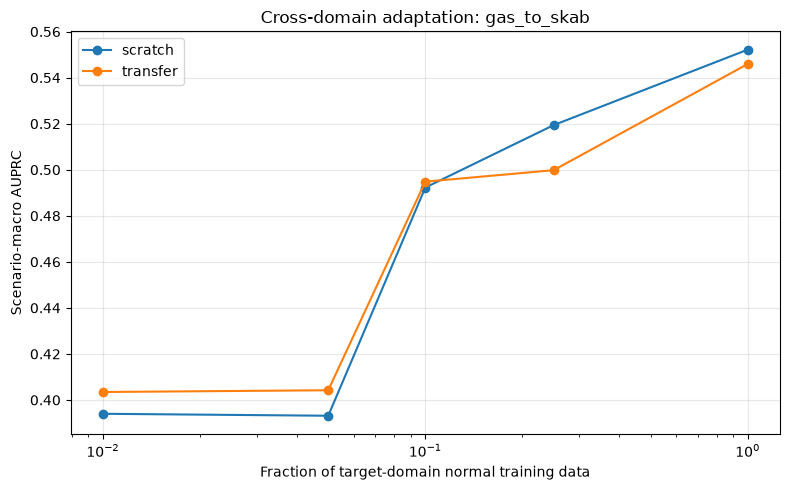

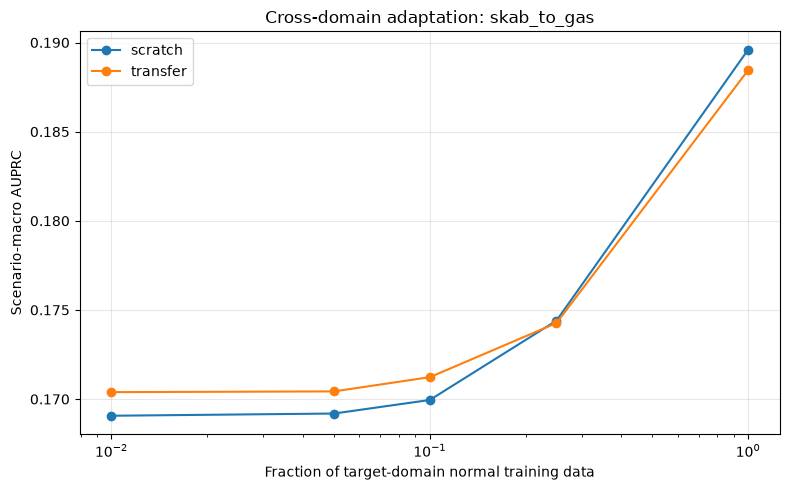

In [10]:
if not transfer.empty:
    for direction, frame in transfer.groupby("direction"):
        fig, ax = plt.subplots(figsize=(8, 5))
        for initialization, subframe in frame.groupby("initialization"):
            ax.plot(subframe["requested_target_fraction"], subframe["auprc_mean"], marker="o", label=initialization)
        ax.set_xscale("log")
        ax.set_xlabel("Fraction of target-domain normal training data")
        ax.set_ylabel("Scenario-macro AUPRC")
        ax.set_title(f"Cross-domain adaptation: {direction}")
        ax.grid(True, alpha=0.3)
        ax.legend()
        fig.tight_layout()
        fig.savefig(figure_dir / f"transfer_{direction}.png", dpi=180)
        plt.show()


## Manuscript-readiness checklist


In [11]:
readiness = pd.read_csv(outputs["manuscript_readiness"])
display(readiness)

pending = readiness[readiness["status"].isin(["fail", "pending"])]
if pending.empty:
    print("All configured manuscript requirements are satisfied.")
else:
    print("The following requirements remain incomplete:")
    display(pending)


,requirement,status,evidence
0,At least three distinct random seeds,pass,5
1,Balanced severity-duration scenario grid,pass,288
2,Full proposed model evaluated in both domains,pass,"gas_sensor,skab"
3,At least two modern SOTA comparators,pending,NaN
4,Proposed-model ablation study,pass,4
5,Cross-domain transfer/adaptation,pass,20
6,Paired statistical comparison,pass,12
7,Sensor localization metrics,pass,40320


The following requirements remain incomplete:


,requirement,status,evidence
3,At least two modern SOTA comparators,pending,NaN


## Files recommended for the Results section

- `results/manuscript_v2/combined/model_summary.csv`
- `results/manuscript_v2/combined/bootstrap_confidence_intervals.csv`
- `results/manuscript_v2/combined/paired_statistical_tests.csv`
- `results/manuscript_v2/combined/cross_domain_summary.csv`
- `results/manuscript_v2/combined/ablation_summary.csv`
- `results/manuscript_v2/combined/transfer_summary.csv`

Do not reuse the preliminary tables created before the revised independent-seed protocol.
